# Train CNN with with Colab (GPU)

## Mounting to google colab, creating folders, loading from google drive...

First, we make a pull from the repository to get the latest version of the code.

In [1]:
%cd /content/Gravitational-Waves-Lab
!git pull
!git status

/content/Gravitational-Waves-Lab
Already up to date.
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [2]:
from pathlib import Path
import numpy as np
from google.colab import drive

drive.mount("/content/drive") # mount the drive

DRIVE_ROOT = Path("/content/drive/MyDrive") # the root of the drive

DATA_ROOT = DRIVE_ROOT / "cbc_pe_data" # the root of the data
DATA_RAW = DATA_ROOT / "raw" # the root of the raw data
DATA_PROCESSED = DATA_ROOT / "processed" # the root of the processed data
MODELS_DIR = DATA_ROOT / "models" # the root of the models
RESULTS_DIR = DATA_ROOT / "results" # the root of the results

for path in [DATA_RAW, DATA_PROCESSED, MODELS_DIR, RESULTS_DIR]: # create the directories if they don't exist
    path.mkdir(parents=True, exist_ok=True)

print("DATA_ROOT:", DATA_ROOT)
print("DATA_RAW:", DATA_RAW)
print("MODELS_DIR:", MODELS_DIR)
print("RESULTS_DIR:", RESULTS_DIR)


## This can be excluded 


# print("Dataset path:", dataset_path)
# print("Dataset exists:", dataset_path.exists())

# if dataset_path.exists():
#     data = np.load(dataset_path)
#     print("Files:", data.files)
#     print("X shape:", data["X"].shape)
#     print("y shape:", data["y"].shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DATA_ROOT: /content/drive/MyDrive/cbc_pe_data
DATA_RAW: /content/drive/MyDrive/cbc_pe_data/raw
MODELS_DIR: /content/drive/MyDrive/cbc_pe_data/models
RESULTS_DIR: /content/drive/MyDrive/cbc_pe_data/results


Clone repository if it doesn't exist

In [3]:
from pathlib import Path
import sys
import os

REPO_ROOT = Path("/content/Gravitational-Waves-Lab")
PROJECT_ROOT = REPO_ROOT / "cbc_pe"

if not REPO_ROOT.exists():
    !git clone https://github.com/victorsh13/Gravitational-Waves-Lab.git /content/Gravitational-Waves-Lab

print("REPO_ROOT exists:", REPO_ROOT.exists())
print("PROJECT_ROOT exists:", PROJECT_ROOT.exists())

REPO_ROOT exists: True
PROJECT_ROOT exists: True


Configure the impots

In [4]:
os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("cwd:", Path.cwd())
print("sys.path[:3]:", sys.path[:3])

cwd: /content/Gravitational-Waves-Lab/cbc_pe
sys.path[:3]: ['/content/Gravitational-Waves-Lab/cbc_pe', '/content', '/env/python']


## Load the data

In [5]:
from src.io import load_dataset_npz

dataset_path = DATA_RAW / "cbc_dataset_500.npz"

print(dataset_path.exists())

batch = load_dataset_npz(dataset_path)

X = batch.X
y = batch.y
network_snrs = batch.network_snrs   
metadata = batch.metadata

print("X:", batch.X.shape)
print("y:", batch.y.shape)
print("network_snrs:", len(batch.network_snrs))
print("metadata:", batch.metadata)


True
X: (500, 3, 16384)
y: (500, 3)
network_snrs: 500
metadata: {'detector_names': ['H1', 'L1', 'V1']}


Split the data into:
- ``train``       : training the model
- ``val``         : early stopping / chosing the best model
- ``calibration`` : calibration of the conformal intervals
- ``test``        : final evaluation, independent of the model/training/calibration

Some reasonable splits: 70/10/10/10 

In [ ]:
import numpy as np


n_samples = X.shape[0]
rng = np.random.default_rng(seed=13)

indices = rng.permutation(n_samples)
split_fractions = [0.7, 0.1, 0.1, 0.1] # Train, Val, Cal, Test

if sum(split_fractions) != 1:
    raise ValueError("Split fractions must sum to 1")

n_train = int(split_fractions[0] * n_samples)
n_val = int(split_fractions[1] * n_samples)
n_cal = int(split_fractions[2] * n_samples)
n_test = n_samples - n_train - n_val - n_cal

print(f"Samples: \n - Train: {n_train}\n - Val: {n_val}\n - Cal: {n_cal}\n - Test: {n_test}")

idx_train = indices[:n_train]
idx_val = indices[n_train:n_train+n_val]
idx_cal = indices[n_train+n_val:n_train+n_val+n_cal]
idx_test = indices[n_train+n_val+n_cal:]

# Save splits to compare models properly
np.savez(
    DATA_PROCESSED / "splits_cbc_dataset_500.npz",
    idx_train=idx_train,
    idx_val=idx_val,
    idx_cal=idx_cal,
    idx_test=idx_test,
)



X_train, y_train = X[idx_train], y[idx_train]
X_val, y_val = X[idx_val], y[idx_val]
X_cal, y_cal = X[idx_cal], y[idx_cal]
X_test, y_test = X[idx_test], y[idx_test]





Samples: 
 - Train: 350
 - Val: 50
 - Cal: 50
 - Test: 50


Standarize the labels using the mean and standard deviation of the training set and save it in DATA_PROCESSED.
This will be needed to revert the normalization and interpret the predictions as physical quantities.

In [ ]:
y_mean = y_train.mean(axis=0)
y_std = y_train.std(axis=0) + 1e-8

y_train_std = (y_train - y_mean) / y_std
y_val_std = (y_val - y_mean) / y_std
y_cal_std = (y_cal - y_mean) / y_std
y_test_std = (y_test - y_mean) / y_std


# Save it in file:
file_name_std = "standardization_params.npz"

np.savez(
    DATA_PROCESSED / file_name_std,
    mean=y_mean,
    std=y_std,
)

Create PyTorch datasets

In [20]:
from src.models.dataset import ArrayRegressionDataset

train_dataset = ArrayRegressionDataset(X_train, y_train_std)
val_dataset = ArrayRegressionDataset(X_val, y_val_std)
cal_dataset = ArrayRegressionDataset(X_cal, y_cal_std)
test_dataset = ArrayRegressionDataset(X_test, y_test_std)

ModuleNotFoundError: No module named 'src.models.dataset'

And loaders

In [9]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
)

cal_loader = DataLoader(
    cal_dataset,
    batch_size=32,
    shuffle=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
)

## Train the CNN and save the model

In [21]:
from src.models.network import SimpleCNN
import torch
import torch.nn as nn

from src.models.train import train_one_epoch, validate_one_epoch


model = SimpleCNN(
    n_detectors=3,
    n_outputs=3,
    embedding_dim=64,
)
# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)


epochs = 10
batch_size = 32
learning_rate = 1e-3

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
loss_fn = nn.MSELoss()


# Cambiar a train_one_epoch
loss_train = []
loss_val = []

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,
)
for epoch in range(epochs):
    epoch_loss = train_one_epoch(model, train_loader, loss_fn, optimizer, device)
    epoch_loss_val = validate_one_epoch(model, val_loader, loss_fn, device)

    loss_train.append(epoch_loss)
    loss_val.append(epoch_loss_val)

    if (epoch+1) % 1 == 0:
        print(
        f"Epoch {epoch+1:03d} | "
        f"train_loss = {epoch_loss:.6f} | "
        f"val_loss = {epoch_loss_val:.6f}"
        )


ImportError: cannot import name 'validate_one_epoch' from 'src.models.train' (/content/Gravitational-Waves-Lab/cbc_pe/src/models/train.py)

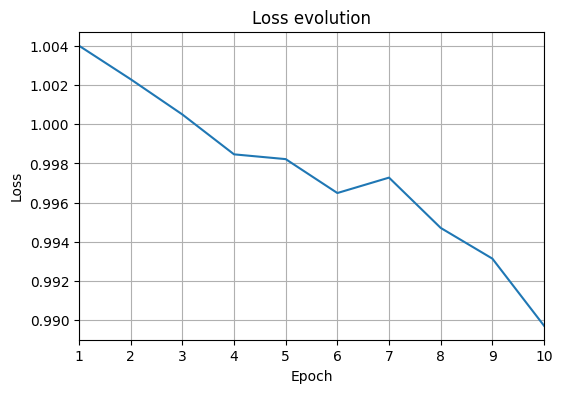

In [19]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(1, 1, figsize=(6, 4))

plt.plot(np.arange(1, epochs+1), mean_loss_train, label="Train")
ax.set_xlim(1, epochs)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Loss evolution")
ax.grid()
